In [31]:
import pandas as pd
from os import makedirs

from hydra.core.analysis.utils import comparison_discovery

In [32]:
root_dir = "../../"

In [33]:
makedirs(f"{root_dir}figures/", exist_ok=True)

In [34]:
results = [results for path, results in comparison_discovery(f"{root_dir}samples")]
df = pd.DataFrame(results)

## Tables

In [35]:
from pathlib import Path

import pandas as pd

def _parse_metric_spec(metric: str) -> tuple[str, bool, bool]:
    """
    Return: (base_metric_name, invert_rank, exclude_from_avg_rank)

    Supports both prefix orders:
      -[n]metric
      [n]-metric
    """
    base = metric.strip()
    invert = False
    exclude_from_avg_rank = False

    changed = True
    while changed:
        changed = False
        if base.startswith("-"):
            invert = True
            base = base[1:]
            changed = True
        if base.startswith("[n]"):
            exclude_from_avg_rank = True
            base = base[3:]
            changed = True

    if not base:
        raise ValueError(f"Invalid metric specification: {metric!r}")

    return base, invert, exclude_from_avg_rank


def build_ranked_df(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    """
    Build the aggregated + ranked dataframe.

    Output layout:
      - for each metric "acc", produces:
            acc        -> mean
            acc_std    -> standard deviation
      - ranking is computed on the mean column only
      - avg_rank is the mean of per-metric ranks
    """

    def _resolve_nested(value, keys: list[str]):
        current = value
        for key in keys:
            if isinstance(current, dict):
                if key not in current:
                    return pd.NA
                current = current[key]
            else:
                return pd.NA
        return current

    def _extract_metric_column(df: pd.DataFrame, metric_name: str) -> pd.Series:
        if metric_name in df.columns:
            return df[metric_name]

        parts = metric_name.split(".")
        root = parts[0]

        if root not in df.columns:
            raise KeyError(
                f"Missing metric '{metric_name}': "
                f"column '{root}' not found in df.columns"
            )

        if len(parts) == 1:
            return df[root]

        return df[root].apply(lambda v: _resolve_nested(v, parts[1:]))

    def _first(x):
        return x[0] if isinstance(x, (list, tuple)) else x

    metric_specs: list[tuple[str, bool, bool]] = []
    seen = set()
    for m in metrics:
        base, invert, exclude_from_avg_rank = _parse_metric_spec(m)
        if base not in seen:
            metric_specs.append((base, invert, exclude_from_avg_rank))
            seen.add(base)

    metric_cols = [base for base, _, _ in metric_specs]

    required_cols = ["name", "dataset_name", "kind"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in df: {missing}")

    df_t = df[required_cols].copy()
    df_t["name"] = df_t["name"].apply(_first)
    df_t["kind"] = df_t["kind"].apply(_first)

    for base in metric_cols:
        df_t[base] = pd.to_numeric(_extract_metric_column(df, base), errors="coerce")

    group_cols = ["dataset_name", "name", "kind"]
    df_grouped = df_t.groupby(group_cols, as_index=False)

    df_mean = df_grouped[metric_cols].mean()
    df_std = df_grouped[metric_cols].std()

    df_agg = df_mean.copy()
    for base in metric_cols:
        df_agg[f"{base}_std"] = df_std[base]

    df_ranked = df_agg.copy()
    rank_cols = []
    for base, invert, exclude_from_avg_rank in metric_specs:
        if exclude_from_avg_rank:
            continue

        rank_col = f"{base}_rank"
        rank_input = -df_ranked[base] if invert else df_ranked[base]
        df_ranked[rank_col] = (
            rank_input.groupby([df_ranked["dataset_name"], df_ranked["kind"]])
            .rank(method="average", ascending=True)
        )
        rank_cols.append(rank_col)

    if rank_cols:
        df_ranked["avg_rank"] = df_ranked[rank_cols].mean(axis=1)
    else:
        df_ranked["avg_rank"] = float("nan")

    df_final = (
        df_ranked.drop(columns=rank_cols)
        .sort_values(["dataset_name", "kind", "avg_rank", "name"], na_position="last")
        .reset_index(drop=True)
    )
    return df_final


def _latex_escape(s: str) -> str:
    return (str(s)
            .replace("\\", r"\textbackslash{}")
            .replace("&", r"\&")
            .replace("%", r"\%")
            .replace("$", r"\$")
            .replace("#", r"\#")
            .replace("_", r"\_")
            .replace("{", r"\{")
            .replace("}", r"\}")
            .replace("~", r"\textasciitilde{}")
            .replace("^", r"\textasciicircum{}"))


def _safe_filename(s: str) -> str:
    s = str(s).strip()
    return "".join(ch if ch.isalnum() or ch in ("-", "_") else "_" for ch in s)


def _pretty_metric_name(metric_name: str) -> str:
    return metric_name.replace("_", r"\_")


def _build_table_caption(dataset_name: str, metrics: list[str] | None = None) -> str:
    metric_descriptions: list[str] = []
    seen = set()

    for m in metrics or []:
        base, invert, exclude_from_avg_rank = _parse_metric_spec(m)
        if base in seen:
            continue
        seen.add(base)

        metric_label = _pretty_metric_name(base)

        if exclude_from_avg_rank:
            metric_descriptions.append(f"{metric_label} (reported only)")
        else:
            direction = "higher is better" if invert else "lower is better"
            metric_descriptions.append(f"{metric_label} ({direction})")

    caption_parts = [
        f"Performance comparison on the {_latex_escape(dataset_name)} dataset.",
        "Methods are grouped by kind.",
    ]

    if metric_descriptions:
        caption_parts.append("Reported metrics: " + ", ".join(metric_descriptions) + ".")

    caption_parts.append(
        r"Colored cells mark the top three values within each kind for ranked metrics "
        r"(green best, yellow second, orange third). Lower avg\_rank is better."
    )

    return " ".join(caption_parts)


def _format_number(value, ndigits: int = 4) -> str:
    if pd.isna(value):
        return ""
    return f"{float(value):.{ndigits}f}"


def _format_mean_pm_std(mean_value, std_value, ndigits: int = 4) -> str:
    if pd.isna(mean_value):
        return ""
    mean_str = _format_number(mean_value, ndigits=ndigits)
    if pd.isna(std_value):
        return mean_str
    std_str = _format_number(std_value, ndigits=ndigits)
    return rf"${mean_str} \pm {std_str}$"


def _render_single_dataset_table(
    ds_df: pd.DataFrame,
    metrics: list[str] | None = None,
    font_cmd: str = r"\footnotesize",
    float_env: str = "table",
    placement: str = "tbp",
    ndigits: int = 4,
) -> str:
    """
    Render a full LaTeX table float for a single dataset.

    Expected input:
      - metric mean columns: <metric>
      - metric std columns:  <metric>_std
    """
    ranked_metric_specs: list[tuple[str, bool]] = []
    ranked_metric_bases: list[str] = []
    seen = set()

    for m in metrics or []:
        base, invert, exclude_from_avg_rank = _parse_metric_spec(m)
        if exclude_from_avg_rank:
            continue
        if base in ds_df.columns and base not in seen:
            ranked_metric_specs.append((base, invert))
            ranked_metric_bases.append(base)
            seen.add(base)

    # Visible columns:
    # - keep identifier columns except dataset_name/kind
    # - keep metric mean columns
    # - hide *_std columns from the header because std is rendered inline as mean ± std
    data_cols: list[str] = []
    for c in ds_df.columns:
        if c in ("dataset_name", "kind"):
            continue
        if c.endswith("_std"):
            continue
        data_cols.append(c)

    ncols = len(data_cols)
    col_format = "l" + "r" * (ncols - 1)

    metric_ranks: dict[str, pd.Series] = {}
    for base, invert in ranked_metric_specs:
        rank_input = -ds_df[base] if invert else ds_df[base]
        metric_ranks[base] = (
            rank_input.groupby(ds_df["kind"])
            .rank(method="min", ascending=True, na_option="keep")
        )

    def _render_cell(col: str, idx, row) -> str:
        if col == "name":
            return _latex_escape(row[col])

        if col == "avg_rank":
            return _format_number(row[col], ndigits=ndigits)

        mean_value = row[col]
        std_value = row.get(f"{col}_std", pd.NA)
        cell_text = _format_mean_pm_std(mean_value, std_value, ndigits=ndigits)

        if col not in metric_ranks or cell_text == "":
            return cell_text

        rank_value = metric_ranks[col].loc[idx]
        if pd.isna(rank_value):
            return cell_text

        if rank_value == 1:
            return rf"\cellcolor{{green!25}}{cell_text}"
        if rank_value == 2:
            return rf"\cellcolor{{yellow!35}}{cell_text}"
        if rank_value == 3:
            return rf"\cellcolor{{orange!35}}{cell_text}"

        return cell_text

    dataset_name = ds_df["dataset_name"].iloc[0]
    caption = _build_table_caption(str(dataset_name), metrics)
    label = f"tab:{_safe_filename(dataset_name).lower()}"

    lines: list[str] = []
    lines.append(rf"\begin{{{float_env}}}[{placement}]")
    lines.append(r"\centering")
    lines.append(font_cmd)
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\vspace{0.25em}")
    lines.append(r"\begin{adjustbox}{max width=\linewidth}")
    lines.append(r"\begin{tabular}{" + col_format + r"}")
    lines.append(r"\toprule")
    lines.append(" & ".join(_latex_escape(c) for c in data_cols) + r" \\")
    lines.append(r"\midrule")

    for kind, k_df in ds_df.groupby("kind", sort=False):
        lines.append(
            rf"\multicolumn{{{ncols}}}{{c}}{{\emph{{{_latex_escape(kind)}}}}} \\"
        )
        lines.append(r"\midrule")

        for idx, row in k_df.iterrows():
            cells = [_render_cell(col, idx, row) for col in data_cols]
            lines.append(" & ".join(cells) + r" \\")

        lines.append(r"\midrule")

    if lines[-1] == r"\midrule":
        lines.pop()

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}%")
    lines.append(r"\end{adjustbox}")
    lines.append(rf"\end{{{float_env}}}")

    return "\n".join(lines)


def make_grouped_latex_table(
    df_final: pd.DataFrame,
    out_path: str | Path,
    metrics: list[str] | None = None,
    root_dir: str = "",
    font_cmd: str = r"\footnotesize",
    float_env: str = "table",
    placement: str = "tbp",
    ndigits: int = 4,
) -> dict[str, str]:
    """
    Create one LaTeX table per dataset_name and save each one to a separate file.
    """
    out_path = Path(out_path)
    if root_dir:
        out_path = Path(root_dir) / out_path

    out_path.parent.mkdir(parents=True, exist_ok=True)

    stem = out_path.stem
    suffix = out_path.suffix or ".tex"

    outputs: dict[str, str] = {}

    for dataset_name, ds_df in df_final.groupby("dataset_name", sort=False):
        ds_df = ds_df.reset_index(drop=True)
        latex_str = _render_single_dataset_table(
            ds_df=ds_df,
            metrics=metrics,
            font_cmd=font_cmd,
            float_env=float_env,
            placement=placement,
            ndigits=ndigits,
        )

        dataset_file = out_path.parent / f"{stem}_{_safe_filename(dataset_name)}{suffix}"
        dataset_file.write_text(latex_str, encoding="utf-8")
        outputs[str(dataset_name)] = latex_str

    return outputs

In [36]:
metrics_kind = {
    "macroscopic.structure": [
        "incidence_matrix_density",
        "largest_connected_component_diameter",
        "clique_expansion_number_of_edges",
        "line_graph_number_of_edges"
    ],
    "macroscopic.size": [
        "number_of_nodes",
        "number_of_hyperedges",
        "largest_connected_component_number_of_nodes",
        "largest_connected_component_number_of_hyperedges"
    ],
    "macroscopic.community": [
        "clique_expansion_modularity",
        "hypergraph_modularity",
        "bipartite_graph_modularity",
        "line_graph_modularity"
    ],
    "mesoscopic.community": [
        "-normalized_mutual_information",
    ],
    "mesoscopic.structural_patterns": [
        "hypergraph_degree_assortativity",
        "number_of_closed_triangles",
        "number_of_open_triangles"
    ],
    "local_statistics": [
        "clique_expansion_average_clustering_coefficient",
        "node_degree_distribution",
    ],
    "conditional_reconstruction": [
        "-hyperedge_recovery.intersection",
        "-hyperedge_recovery.jaccard_similarity"
    ],
    "higher_order_dissimilarity_measures": [
        "hyper_net_simile",
        "hyper_portrait_divergence"
    ],
}

for kind, metrics in metrics_kind.items():
    df_final = build_ranked_df(df, metrics)

    if kind == "conditional_reconstruction":
        df_final = df_final[df_final["kind"] != "unconditional"]
    if kind == "mesoscopic.community":
        df_final = df_final[df_final["kind"] != "unconditional"]

    df_latex = (
        df_final
        .set_index(["dataset_name", "kind"])
        .sort_index()
    )

    makedirs(f"{root_dir}tables/", exist_ok=True)
    make_grouped_latex_table(
        df_final=df_final,
        out_path=f"tables/{kind}.tex",
        metrics=metrics,  # <- pass metric specs here
        root_dir=root_dir,
        font_cmd=r"\footnotesize",
    )

In [37]:
df_final = build_ranked_df(df, [
    "clique_expansion_modularity",
    "hypergraph_modularity",
    "bipartite_graph_modularity",
    "line_graph_modularity"
])

In [38]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def _resolve_nested(value, keys: list[str]):
    current = value
    for key in keys:
        if isinstance(current, dict):
            if key not in current:
                return pd.NA
            current = current[key]
        else:
            return pd.NA
    return current


def _extract_metric_column(df: pd.DataFrame, metric_name: str) -> pd.Series:
    if metric_name in df.columns:
        return df[metric_name]

    parts = metric_name.split(".")
    root = parts[0]

    if root not in df.columns:
        raise KeyError(
            f"Missing metric '{metric_name}': "
            f"column '{root}' not found in df.columns"
        )

    if len(parts) == 1:
        return df[root]

    return df[root].apply(lambda v: _resolve_nested(v, parts[1:]))


def _first(x):
    return x[0] if isinstance(x, (list, tuple)) else x


def _prepare_aggregated_metric_df(
    df: pd.DataFrame,
    metrics_kind: dict[str, list[str]],
) -> pd.DataFrame:
    """
    Build a dataframe aggregated over repeated runs:
    one row per (dataset_name, name, kind), with one numeric column per metric.
    """
    required_cols = ["name", "dataset_name", "kind"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in df: {missing}")

    # collect all unique base metrics used across groups
    metric_specs = []
    seen = set()
    for group_metrics in metrics_kind.values():
        for m in group_metrics:
            base, invert, exclude_from_avg_rank = _parse_metric_spec(m)
            if base not in seen:
                metric_specs.append((base, invert, exclude_from_avg_rank))
                seen.add(base)

    metric_cols = [base for base, _, _ in metric_specs]

    df_t = df[required_cols].copy()
    df_t["name"] = df_t["name"].apply(_first)
    df_t["kind"] = df_t["kind"].apply(_first)

    for base in metric_cols:
        df_t[base] = pd.to_numeric(_extract_metric_column(df, base), errors="coerce")

    df_agg = (
        df_t.groupby(["dataset_name", "name", "kind"], as_index=False)
        .mean(numeric_only=True)
    )
    return df_agg

def compute_reverse_rank_scores(
    df: pd.DataFrame,
    metrics_kind: dict[str, list[str]],
    agg: str = "mean",
) -> pd.DataFrame:
    """
    Compute reverse-rank scores for each:
        (dataset_name, kind, metric_group, model_name)

    Reverse-rank is:
        n_models - rank + 1

    Ranking is computed independently for each metric inside each
    (dataset_name, kind) block.

    Then, for each metric group, reverse-rank values are aggregated across
    all metrics in that group using agg in {"mean", "sum"}.
    """
    if agg not in {"mean", "sum"}:
        raise ValueError("agg must be either 'mean' or 'sum'")

    df_agg = _prepare_aggregated_metric_df(df, metrics_kind)

    long_parts = []

    for metric_group, metrics in metrics_kind.items():
        group_df = df_agg.copy()

        # match your reference behavior
        if metric_group == "conditional_reconstruction":
            group_df = group_df[group_df["kind"] != "unconditional"].copy()
        if metric_group == "mesoscopic.community":
            group_df = group_df[group_df["kind"] != "unconditional"].copy()

        metric_scores = []

        for metric_spec in metrics:
            base, invert, _ = _parse_metric_spec(metric_spec)

            if base not in group_df.columns:
                continue

            rank_input = -group_df[base] if invert else group_df[base]

            group_keys = [group_df["dataset_name"], group_df["kind"]]

            ranks = rank_input.groupby(group_keys).rank(
                method="average",
                ascending=True,
                na_option="keep",
            )

            n_models = rank_input.groupby(group_keys).transform("count")
            reverse_rank = n_models - ranks + 1

            metric_scores.append(
                pd.DataFrame(
                    {
                        "dataset_name": group_df["dataset_name"],
                        "kind": group_df["kind"],
                        "name": group_df["name"],
                        "metric_group": metric_group,
                        "metric": base,
                        "reverse_rank": reverse_rank,
                    }
                )
            )

        if not metric_scores:
            continue

        long_group = pd.concat(metric_scores, ignore_index=True)

        agg_fun = "mean" if agg == "mean" else "sum"
        group_scores = (
            long_group.groupby(
                ["dataset_name", "kind", "name", "metric_group"],
                as_index=False
            )["reverse_rank"]
            .agg(agg_fun)
            .rename(columns={"reverse_rank": "score"})
        )

        long_parts.append(group_scores)

    if not long_parts:
        raise ValueError("No valid metrics were found to compute reverse-rank scores.")

    score_df = pd.concat(long_parts, ignore_index=True)

    # keep metric-group order from metrics_kind
    metric_group_order = list(metrics_kind.keys())
    score_df["metric_group"] = pd.Categorical(
        score_df["metric_group"],
        categories=metric_group_order,
        ordered=True,
    )

    return score_df.sort_values(
        ["dataset_name", "kind", "metric_group", "score", "name"],
        ascending=[True, True, True, False, True],
    ).reset_index(drop=True)

import pandas as pd
import matplotlib.pyplot as plt

def build_model_color_map(
    score_df: pd.DataFrame,
    cmap_name: str = "tab20",
) -> dict[str, tuple[float, float, float, float]]:
    """
    Assign a consistent color to each model, ensuring that
    models with the same `kind` have distinct colors.
    """
    color_map = {}

    # Group models by kind
    grouped = (
        score_df[["name", "kind"]]
        .dropna()
        .astype(str)
        .drop_duplicates()
        .groupby("kind")
    )

    for kind, group in grouped:
        model_names = sorted(group["name"].unique().tolist())

        # Create a colormap sized for this specific kind
        cmap = plt.get_cmap(cmap_name, max(len(model_names), 1))

        for i, model in enumerate(model_names):
            color_map[model] = cmap(i)

    return color_map

def plot_reverse_rank_grid_per_kind(
    score_df: pd.DataFrame,
    metrics_kind: dict[str, list[str]],
    out_dir: str | Path | None = None,
    agg: str = "mean",
    figsize_per_panel: tuple[float, float] = (4.2, 3.0),
    rotate_xticks: int = 45,
    show_values: bool = True,
    model_color_map: dict[str, tuple[float, float, float, float]] | None = None,
    cmap_name: str = "tab20",
    add_legend: bool = True,
    show_xticks: bool = True,
    highlight_models: list[str] | None = None,
    highlight_hatch: str = "//",
    bar_width: float = 0.6,
    panel_spacing: float | None = None,
) -> dict[str, tuple[plt.Figure, pd.DataFrame]]:
    """
    For each kind, create a grid of barplots:
      - rows    -> dataset_name
      - columns -> metric groups that contain at least one subplot for this kind
      - bars    -> models
      - height  -> aggregated reverse-rank score

    Empty metric-group columns are automatically removed.

    Parameters
    ----------
    show_xticks:
        If False, hide x tick marks and x tick labels on all subplots.

    highlight_models:
        List of model names to emphasize with a hatch pattern.

    highlight_hatch:
        Hatch pattern for highlighted models.

    bar_width:
        Width of the bars passed to matplotlib.
    """
    out = {}
    metric_group_order = list(metrics_kind.keys())
    highlight_models_set = set(highlight_models or [])

    if model_color_map is None:
        model_color_map = build_model_color_map(score_df, cmap_name=cmap_name)

    if out_dir is not None:
        out_dir = Path(out_dir)
        out_dir.mkdir(parents=True, exist_ok=True)

    for kind_value, k_df in score_df.groupby("kind", sort=False):
        k_df = k_df.copy()

        dataset_order = list(
            k_df["dataset_name"].dropna().astype(str).sort_values().unique()
        )

        active_metric_groups = [
            metric_group
            for metric_group in metric_group_order
            if not k_df[k_df["metric_group"].astype(str) == metric_group].empty
        ]

        if not active_metric_groups:
            continue

        nrows = len(dataset_order)
        ncols = len(active_metric_groups)

        fig_w = max(1, ncols) * figsize_per_panel[0]
        fig_h = max(1, nrows) * figsize_per_panel[1]

        fig, axes = plt.subplots(
            nrows=nrows,
            ncols=ncols,
            figsize=(fig_w, fig_h),
            squeeze=False,
            sharey=False,
        )

        dataset_max_map = (
            k_df.groupby("dataset_name")["score"]
            .max()
            .fillna(1.0)
            .to_dict()
        )

        for i, dataset_name in enumerate(dataset_order):
            for j, metric_group in enumerate(active_metric_groups):
                ax = axes[i, j]

                sub = k_df[
                    (k_df["dataset_name"].astype(str) == dataset_name)
                    & (k_df["metric_group"].astype(str) == metric_group)
                ].copy()

                if sub.empty:
                    ax.set_axis_off()
                    continue

                sub = sub.sort_values(["score", "name"], ascending=[False, True])

                bar_colors = [
                    model_color_map.get(str(model), "#777777")
                    for model in sub["name"]
                ]

                bars = ax.bar(
                    sub["name"],
                    sub["score"],
                    color=bar_colors,
                    width=bar_width,
                )

                for bar, model in zip(bars, sub["name"]):
                    if str(model) in highlight_models_set:
                        bar.set_hatch(highlight_hatch)
                    # Set border
                    bar.set_edgecolor("black")
                    bar.set_linewidth(1)

                dataset_max = dataset_max_map.get(dataset_name, 1.0)
                ax.set_ylim(0, dataset_max * 1.15 if dataset_max > 0 else 1)

                if i == 0:
                    ax.set_title(metric_group)

                if j == 0:
                    ax.set_ylabel(f"{dataset_name}")
                    ax.tick_params(axis="y", left=True, labelleft=True)
                else:
                    ax.set_ylabel("")
                    ax.tick_params(axis="y", left=False, labelleft=False)
                    ax.spines["left"].set_visible(False)

                if show_xticks:
                    ax.tick_params(axis="x", rotation=rotate_xticks, bottom=True, labelbottom=True)
                else:
                    ax.tick_params(axis="x", bottom=False, labelbottom=False)

                if show_values:
                    for patch, value in zip(bars, sub["score"]):
                        ax.annotate(
                            f"{value:.2f}",
                            (patch.get_x() + patch.get_width() / 2, patch.get_height()),
                            ha="center",
                            va="bottom",
                            fontsize=20,
                            xytext=(0, 2),
                            textcoords="offset points",
                        )

        if add_legend:
            legend_models = sorted(k_df["name"].dropna().astype(str).unique().tolist())
            handles = []
            for m in legend_models:
                rect = plt.Rectangle(
                    (0, 0),
                    1,
                    1,
                    facecolor=model_color_map[m],
                )
                if m in highlight_models_set:
                    rect.set_hatch(highlight_hatch)
                handles.append(rect)

            fig.legend(
                handles,
                legend_models,
                loc="upper center",
                ncol=min(len(legend_models), 7),
                bbox_to_anchor=(0.5, 1.05),
                frameon=False,
            )

        if panel_spacing is None:
            fig.tight_layout()
        else:
            fig.tight_layout(pad=panel_spacing)

        if out_dir is not None:
            file_name = f"{_safe_filename(kind_value)}_reverse_rank_grid.pdf"
            fig.savefig(out_dir / file_name, dpi=200, bbox_inches="tight")

        out[str(kind_value)] = (fig, k_df)

    return out

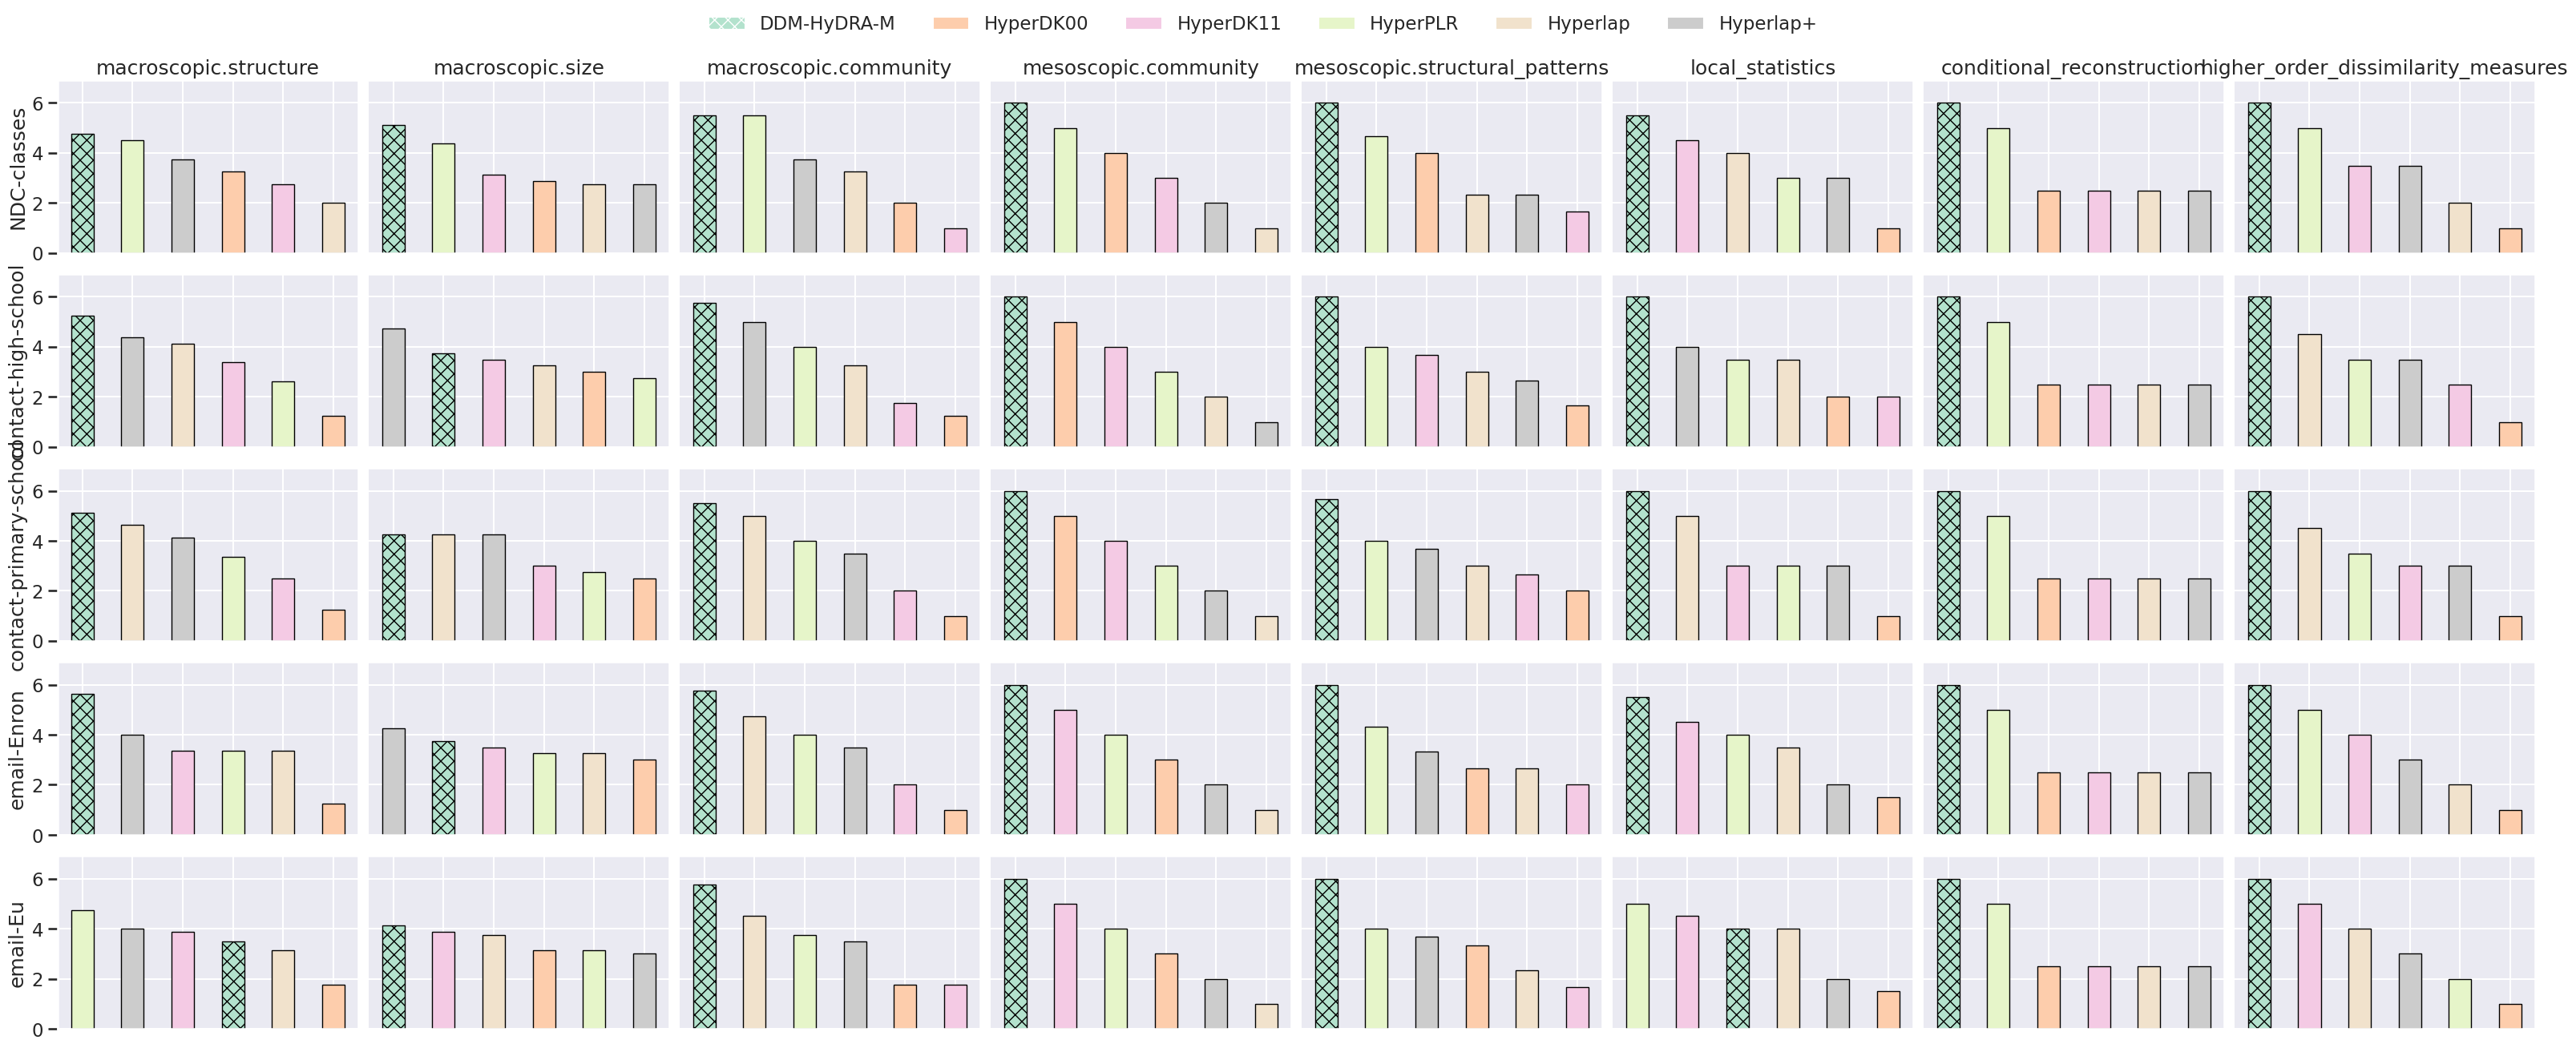

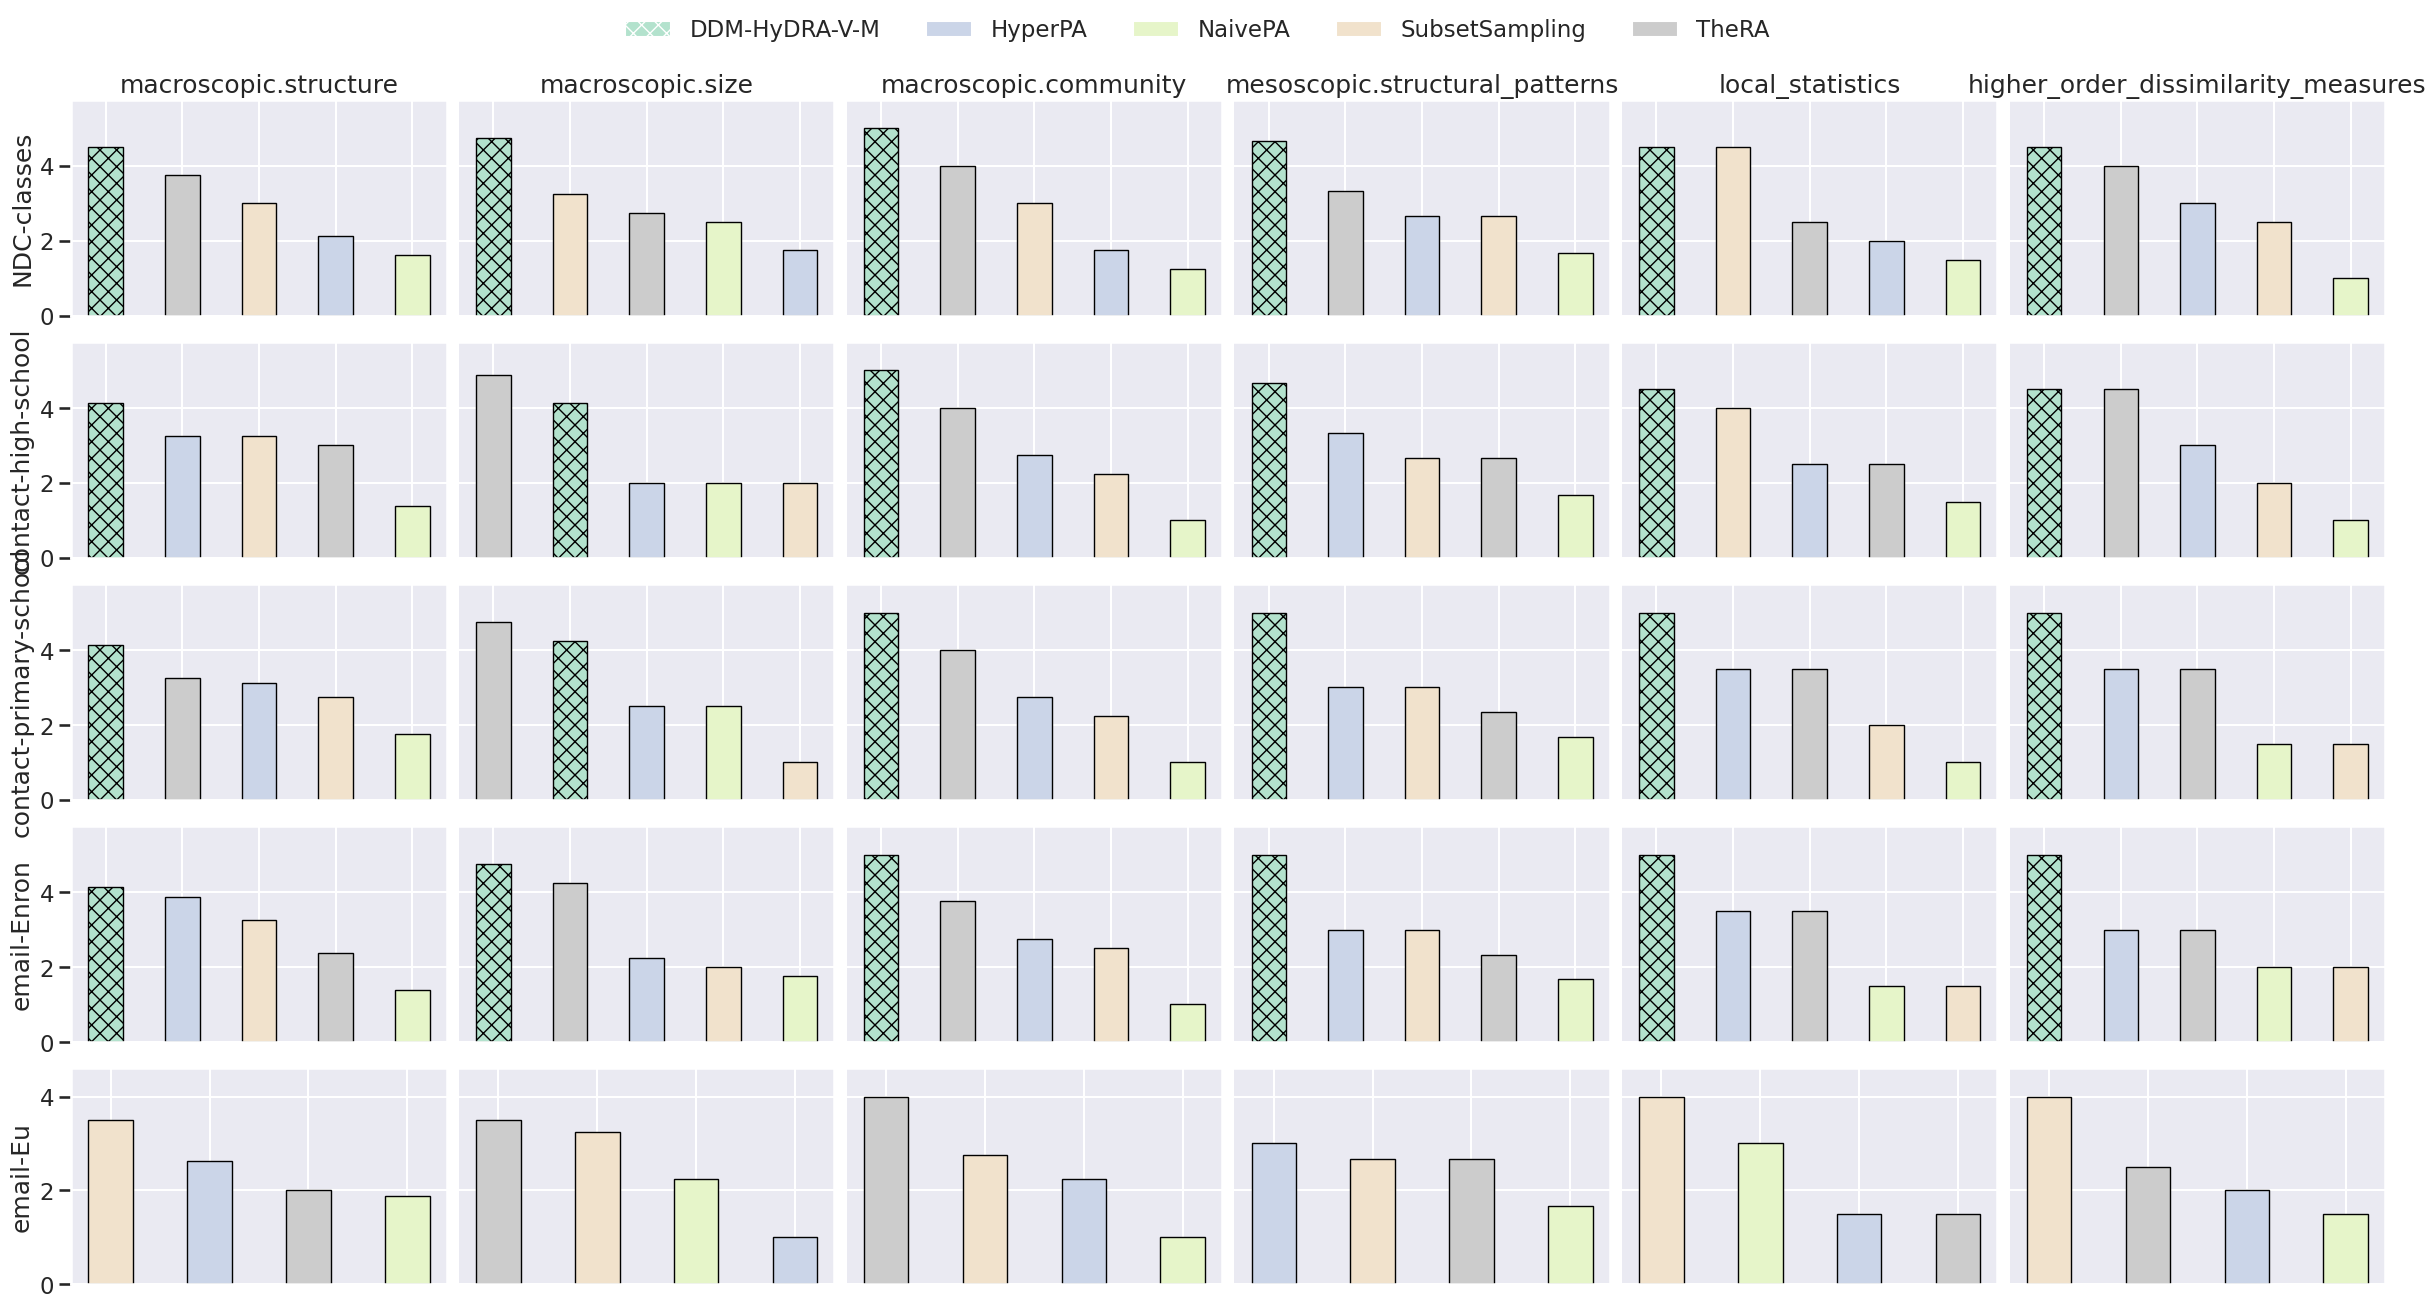

In [40]:
score_df = compute_reverse_rank_scores(
    df=df,
    metrics_kind=metrics_kind,
    agg="mean",   # change to "sum" if you want total reverse-rank per group
)

score_df = score_df[score_df['kind'] != 'reconstruction']
score_df['dataset_name'] = score_df['dataset_name'].astype(str).str.split("/").str[-1]

model_color_map = build_model_color_map(score_df, cmap_name="Pastel2")

import seaborn as sns
sns.set_theme(
    # context="poster",
    context="talk",
    style="darkgrid",
)

figures = plot_reverse_rank_grid_per_kind(
    score_df=score_df,
    metrics_kind=metrics_kind,
    out_dir=f"{root_dir}figures",
    agg="mean",
    model_color_map=model_color_map,
    add_legend=True,
    rotate_xticks=90,
    figsize_per_panel=(4.0, 2.5),
    show_values=False,
    show_xticks=False,
    highlight_models=["DDM-HyDRA-M", "DDM-HyDRA-V-M"],
    highlight_hatch="xx",
    bar_width=0.45,
    panel_spacing=0.5
)

plt.show()

## Higher-order dissimilarity measures for hypergraph comparison

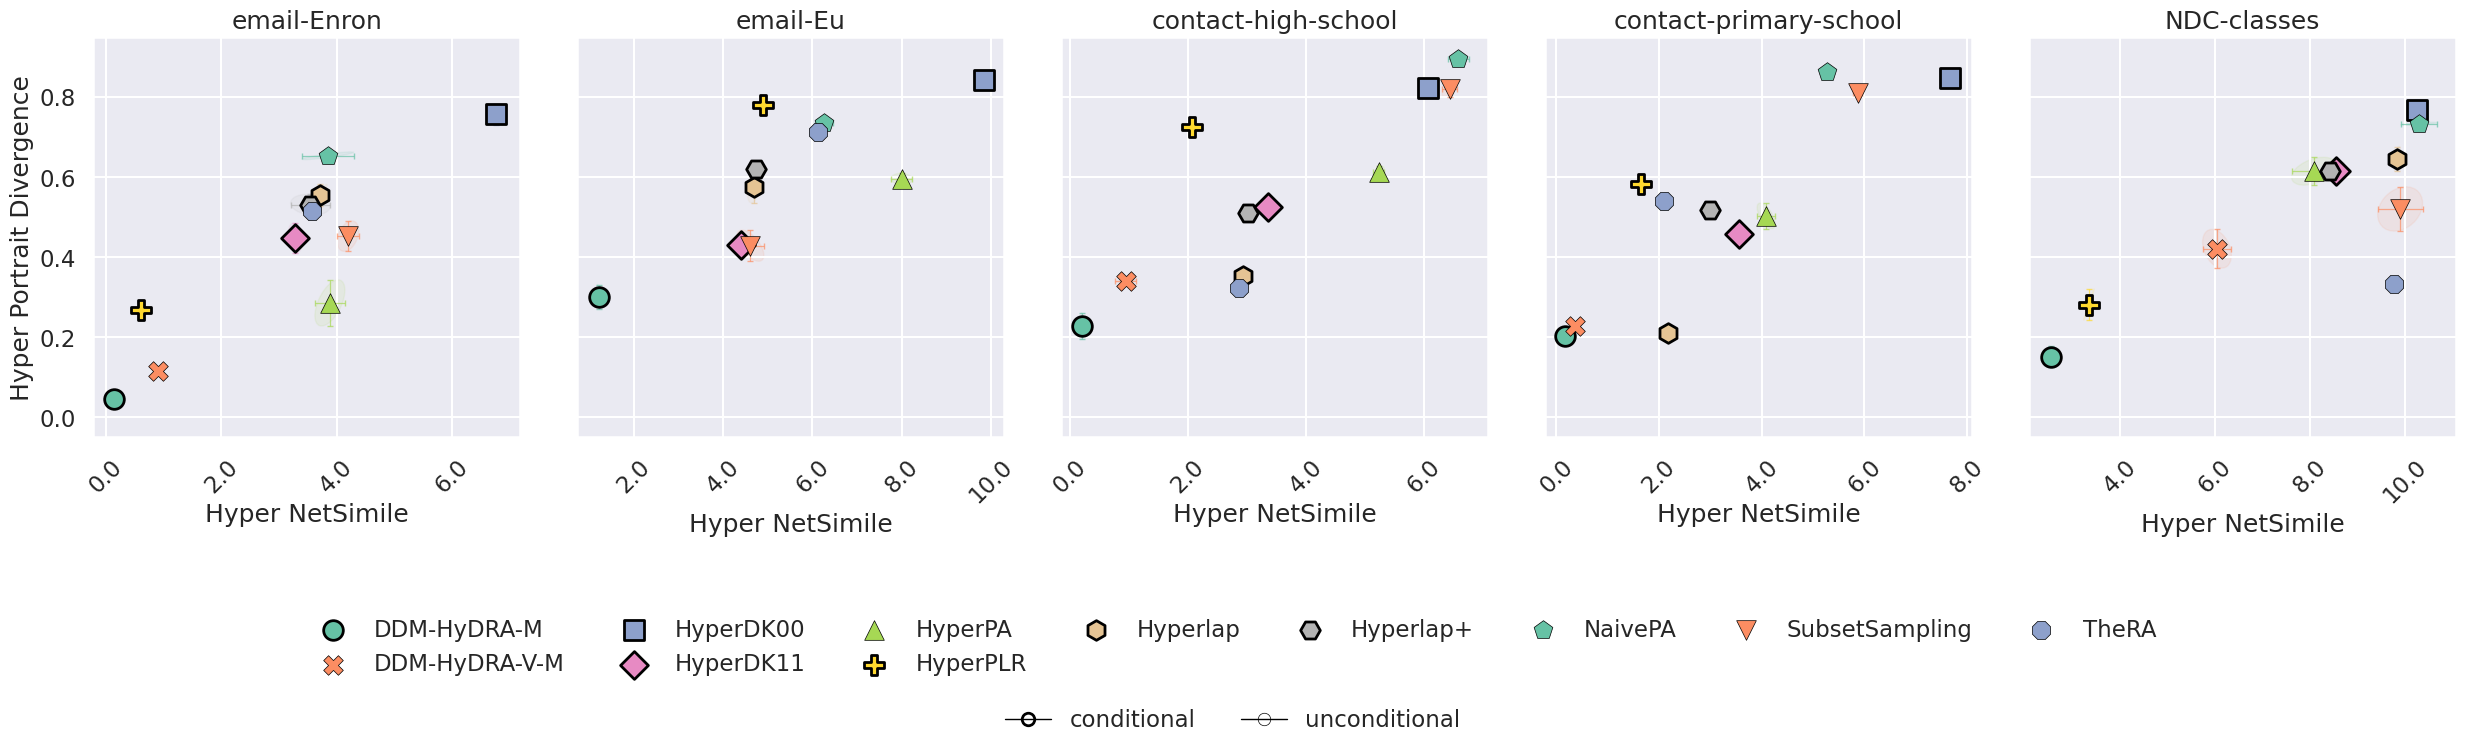

In [41]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse

df_dissimilarity = df.copy()

def _scalarize(x, *, lower=False):
    """If x is a 1-element container, unwrap it. If it's a string, keep it intact."""
    if isinstance(x, (list, tuple, np.ndarray)):
        if len(x) == 0:
            return np.nan
        x = x[0]
    if isinstance(x, str):
        x = x.strip()
        if lower:
            x = x.lower()
    return x

# Normalize ONCE (prevents "ModelA" vs "M" bugs)
df_dissimilarity["name"] = df_dissimilarity["name"].apply(_scalarize)
df_dissimilarity["kind"] = df_dissimilarity["kind"].apply(lambda v: _scalarize(v, lower=True))
df_dissimilarity = df_dissimilarity[df_dissimilarity['kind'] != 'reconstruction']

def covariance_ellipse(
    ax, x, y, *, n_std=1.0, edgecolor="k", facecolor="none",
    alpha=0.12, lw=1.0, zorder=0
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 3:
        return
    cov = np.cov(x, y)
    if not np.all(np.isfinite(cov)):
        return

    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]

    width, height = 2 * n_std * np.sqrt(np.maximum(vals, 0))
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))

    ell = Ellipse(
        (x.mean(), y.mean()),
        width, height,
        angle=angle,
        edgecolor=edgecolor,
        facecolor=facecolor,
        alpha=alpha,
        lw=lw,
        label="_nolegend_",
        zorder=zorder,
    )
    ax.add_patch(ell)

def _kind_proxy_handle(edgecolor, linewidth, linestyle):
    return Line2D(
        [0], [0],
        marker="o",
        linestyle=linestyle,
        color=edgecolor,
        markerfacecolor="none",
        markeredgecolor=edgecolor,
        markeredgewidth=linewidth,
        linewidth=1.0,
    )

KIND_EDGE_CONFIGS = [
    {"kinds": ["conditional"], "label": "conditional", "edgecolor": "black", "linewidth": 2.0, "linestyle": "solid"},
    {"kinds": ["unconditional"], "label": "unconditional", "edgecolor": "black", "linewidth": 0.5, "linestyle": "solid"},
    # {"kinds": ["reconstruction"], "label": "reconstruction", "edgecolor": "orange", "linewidth": 1.0, "linestyle": "solid"},
]

def kind_edge_style(kind):
    kind = _scalarize(kind, lower=True)
    for cfg in KIND_EDGE_CONFIGS:
        kinds = cfg.get("kinds", [])
        if isinstance(kinds, str):
            kinds = [kinds]
        if kind in kinds:
            return {k: v for k, v in cfg.items() if k != "kinds"}
    raise ValueError(f"Kind '{kind}' not found in any KIND_EDGE_CONFIGS entry")

available_datasets = list(df_dissimilarity["dataset_name"].unique())
DATASET_ORDER = [
    "daqh/email-Enron",
    "daqh/email-Eu",
    "daqh/contact-high-school",
    "daqh/contact-primary-school",
    "daqh/NDC-classes"
]

def ordered_datasets(available, order=None, *, strict=True):
    if not order:
        return available
    missing = [d for d in order if d not in available]
    if missing and strict:
        raise ValueError(f"DATASET_ORDER contains unknown dataset_name(s): {missing}")
    ordered = [d for d in order if d in available]
    remainder = [d for d in available if d not in ordered]
    return ordered + remainder

unique_datasets = ordered_datasets(available_datasets, DATASET_ORDER, strict=True)

# consistent names across all subplots
all_names = sorted(df_dissimilarity["name"].dropna().unique())

# markers (one per name)
marker_list = ["o", "X", "s", "D", "^", "P", "h", "H", "p", "v", "8", ">", "*"]
marker_cycle = itertools.cycle(marker_list)
marker_map = {n: next(marker_cycle) for n in all_names}

# colors (one per name, fixed across all subplots)
palette = sns.color_palette("Set2", n_colors=len(all_names))
color_map = dict(zip(all_names, palette))

sns.set_theme(style="darkgrid", context="talk")

fig, ax = plt.subplots(ncols=len(unique_datasets), figsize=(5 * len(unique_datasets), 7))
if len(unique_datasets) == 1:
    ax = [ax]

# for the global legend (use actual plotted artists)
name_handles = {}

for i, dataset_name in enumerate(unique_datasets):
    df_raw = df_dissimilarity[df_dissimilarity["dataset_name"] == dataset_name][
        ["name", "kind", "hyper_net_simile", "hyper_portrait_divergence"]
    ].copy()

    df_stats = (
        df_raw.groupby("name", as_index=False)
        .agg(
            kind=("kind", lambda s: s.mode().iloc[0] if not s.mode().empty else s.iloc[0]),
            x_mean=("hyper_net_simile", "mean"),
            x_std=("hyper_net_simile", "std"),
            y_mean=("hyper_portrait_divergence", "mean"),
            y_std=("hyper_portrait_divergence", "std"),
        )
    )

    for _, r in df_stats.iterrows():
        n = r["name"]
        c = color_map[n]
        m = marker_map[n]
        es = kind_edge_style(r["kind"])

        sc = ax[i].scatter(
            r["x_mean"], r["y_mean"],
            s=200,
            marker=m,
            c=[c],
            edgecolors=es["edgecolor"],
            linewidths=es["linewidth"],
            linestyles=es["linestyle"],
            zorder=2,
            label="_nolegend_",
        )
        # store first-seen handle (not just i==0)
        if n not in name_handles:
            name_handles[n] = sc

        if np.isfinite(r["x_std"]) and np.isfinite(r["y_std"]):
            ax[i].errorbar(
                r["x_mean"], r["y_mean"],
                xerr=r["x_std"], yerr=r["y_std"],
                fmt="none",
                ecolor=c,
                elinewidth=0.9,
                capsize=2,
                alpha=0.7,
                zorder=1,
                label="_nolegend_",
            )

        sub = df_raw[df_raw["name"] == n]
        covariance_ellipse(
            ax[i],
            sub["hyper_net_simile"],
            sub["hyper_portrait_divergence"],
            n_std=1.0,
            edgecolor=c,
            facecolor=c,
            alpha=0.10,
            lw=1.0,
            zorder=0,
        )

    ax[i].set_title(dataset_name.split("/")[-1])
    ax[i].set_xlabel("Hyper NetSimile")
    ax[i].set_ylabel("Hyper Portrait Divergence" if i == 0 else "")
    ax[i].set_ylim(-0.05, 0.95)

    if i != 0:
        ax[i].tick_params(axis="y", left=False, labelleft=False)

    ax[i].tick_params(axis="x", rotation=45)
    ax[i].xaxis.set_major_formatter(plt.FormatStrFormatter("%.1f"))
    ax[i].yaxis.set_major_formatter(plt.FormatStrFormatter("%.1f"))

handles = [name_handles[n] for n in all_names if n in name_handles]
labels = [n for n in all_names if n in name_handles]

fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=max(1, int(len(labels) / 1.3)),
    frameon=False,
)

kind_handles = []
kind_labels = []
for cfg in KIND_EDGE_CONFIGS:
    kind_handles.append(_kind_proxy_handle(cfg["edgecolor"], cfg["linewidth"], cfg["linestyle"]))
    kind_labels.append(cfg.get("label", ",".join(cfg.get("kinds", []))))

fig.legend(
    kind_handles,
    kind_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.10),
    ncol=len(kind_labels),
    frameon=False,
)

fig.tight_layout()
fig.subplots_adjust(bottom=0.35)
makedirs(f"{root_dir}figures/", exist_ok=True)
fig.savefig(f"{root_dir}figures/dissimilarity_scatter.pdf", format="pdf", bbox_inches="tight")